In [ ]:
from __future__ import annotations
import PIL.ImageOps
import PIL.ImageFont
import PIL.ImageDraw
import PIL.Image
import flax
import requests
import PIL
import optax
import numpy as np
from matplotlib.ticker import MaxNLocator
import matplotlib.style as style
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib import colors
from jax.tree_util import tree_leaves, tree_map
import jax.random as random
import jax.numpy as jnp
from jax.lax import conv_general_dilated_patches
from jax import grad

import os

from functools import partial
from pathlib import Path
from typing import Literal
import importlib
import itertools
import math

from collections import namedtuple
from datetime import datetime
from functools import partial
import io
import itertools
from base64 import b64decode
from typing import List, Optional, Sequence, Tuple

from einops import rearrange
import flax.linen as nn
import flax.linen as nn
from IPython.display import HTML, Image, clear_output
import jax
print(jax.__version__)


os.environ['FFMPEG_BINARY'] = 'ffmpeg'


jax.clear_caches()
print('jax', jax.__version__)
print('flax', flax.__version__)
print('optax', optax.__version__)

0.9.0.1
jax 0.9.0.1
flax 0.12.4
optax 0.2.6


In [ ]:
PASS_THROUGH_GATE = 3
DEFAULT_PASS_VALUE = 10.0
NUMBER_OF_GATES = 16
LIGHT_TRUTH_TABLE_SIZE = 4
TRUTH_TABLE_BIT_WEIGHTS = jnp.asarray([8, 4, 2, 1], dtype=jnp.int32)

"""
Fire rate for asynchronicity.

60% of cells will perform the update,
40% will have the update masked.
"""
FIRE_RATE = 0.6

TARGET_EMOJI = "🦎"
TARGET_SIZE_EMOJI = 20
TARGET_SIZE_G = 16
TARGET_SIZE_ASYNC = 14
TARGET_SIZE = 16


GATE_NAMES = [
    'FALSE',
    'AND',
    'A_AND_NOT_B',
    'A',
    'NOT_A_AND_B',
    'B',
    'XOR',
    'OR',
    'NOR',
    'XNOR',
    'NOT_B',
    'A_OR_NOT_B',
    'NOT_A',
    'NOT_A_OR_B',
    'NAND',
    'TRUE',
]

LIGHT_TRUTH_TABLE_NAMES = ['00', '01', '10', '11']

ConnectionType = Literal['random', 'unique']
LogicFamily = Literal['full', 'light']
WirePair = tuple[jax.Array, jax.Array]
UpdatePerceivePair = tuple[jax.Array, jax.Array]


def get_unique_connections(in_dim: int, out_dim: int, key: jax.Array) -> WirePair:
    if out_dim * 2 < in_dim:
        raise ValueError(
            'unique connections require out_dim * 2 >= in_dim: '
            f'{out_dim=} {in_dim=}'
        )

    x = jnp.arange(in_dim)
    a = x[::2]
    b = x[1::2]
    m = min(a.shape[0], b.shape[0])
    a = a[:m]
    b = b[:m]

    if a.shape[0] < out_dim:
        a_ = x[1::2]
        b_ = x[2::2]
        m = min(a_.shape[0], b_.shape[0])
        a = jnp.concatenate([a, a_[:m]])
        b = jnp.concatenate([b, b_[:m]])

    offset = 2
    while out_dim > a.shape[0] and offset < in_dim:
        a = jnp.concatenate([a, x[:-offset]])
        b = jnp.concatenate([b, x[offset:]])
        offset += 1

    if a.shape[0] < out_dim:
        raise ValueError(
            f'Could not generate enough unique connections: {a.shape[0]} < {out_dim}'
        )

    a = a[:out_dim]
    b = b[:out_dim]
    perm = jax.random.permutation(key, out_dim)
    return a[perm], b[perm]


def logic_family_of_logits(logits: jax.Array) -> LogicFamily:
    if logits.shape[-1] == LIGHT_TRUTH_TABLE_SIZE:
        return 'light'
    if logits.shape[-1] == NUMBER_OF_GATES:
        return 'full'
    raise ValueError(f'Unsupported gate parameter size: {logits.shape[-1]}')


def truth_table_bits_to_gate_id(bits: jax.Array) -> jax.Array:
    bits = bits.astype(jnp.int32)
    return jnp.sum(bits * TRUTH_TABLE_BIT_WEIGHTS, axis=-1).astype(jnp.int32)


def hard_gate_ids_from_logits(logits: jax.Array) -> jax.Array:
    logic_family = logic_family_of_logits(logits)
    if logic_family == 'light':
        return truth_table_bits_to_gate_id(decode_light_hard(logits))
    return jnp.argmax(logits, axis=-1).astype(jnp.int32)


def bin_op_all_combinations(a: jax.Array, b: jax.Array) -> jax.Array:
    return jnp.stack(
        [
            jnp.zeros_like(a),
            a * b,
            a - a * b,
            a,
            b - a * b,
            b,
            a + b - 2 * a * b,
            a + b - a * b,
            1 - (a + b - a * b),
            1 - (a + b - 2 * a * b),
            1 - b,
            1 - b + a * b,
            1 - a,
            1 - a + a * b,
            1 - a * b,
            jnp.ones_like(a),
        ],
        axis=-1,
    )


def bin_op_s(a: jax.Array, b: jax.Array, gate_weights: jax.Array) -> jax.Array:
    return jnp.sum(bin_op_all_combinations(a, b) * gate_weights[None, ...], axis=-1)

# def bin_op_s(a: jax.Array, b: jax.Array, gate_weights: jax.Array) -> jax.Array:
#     return jnp.sum(bin_op_all_combinations(a, b) * gate_weights, axis=-1)


def light_truth_table_basis(a: jax.Array, b: jax.Array) -> jax.Array:
    return jnp.stack(
        [
            (1.0 - a) * (1.0 - b),
            (1.0 - a) * b,
            a * (1.0 - b),
            a * b,
        ],
        axis=-1,
    )


# def bin_op_light(a: jax.Array, b: jax.Array, truth_table_weights: jax.Array) -> jax.Array:
#     return jnp.sum(light_truth_table_basis(a, b) * truth_table_weights, axis=-1)

def bin_op_light(a: jax.Array, b: jax.Array, truth_table_weights: jax.Array) -> jax.Array:
    return jnp.sum(light_truth_table_basis(a, b) * truth_table_weights[None, ...], axis=-1)


def decode_soft(logits: jax.Array) -> jax.Array:
    return jax.nn.softmax(logits, axis=-1)


def decode_gumbel_soft(
    logits: jax.Array,
    key: jax.Array,
    temperature: float = 1.0,
) -> jax.Array:
    temperature = jnp.maximum(temperature, 1e-6)
    noise = jax.random.gumbel(key, logits.shape)
    return jax.nn.softmax((logits + noise) / temperature, axis=-1)


def decode_gumbel_st(
    logits: jax.Array,
    key: jax.Array,
    temperature: float = 1.0,
) -> jax.Array:
    # PyTorch parity for full-gate gumbel: gumbel_softmax(..., hard=True).
    y_soft = decode_gumbel_soft(logits, key, temperature)
    y_hard = jax.nn.one_hot(jnp.argmax(y_soft, axis=-1),
                            logits.shape[-1], dtype=y_soft.dtype)
    return y_soft + jax.lax.stop_gradient(y_hard - y_soft)


def decode_dirichlet_sample(
    logits: jax.Array,
    key: jax.Array,
    eps: float = 1e-6,
) -> jax.Array:
    # PyTorch parity for full-gate dirichlet: alpha = softplus(weights), then sample.
    alpha = jax.nn.softplus(logits) + eps
    return jax.random.dirichlet(key, alpha)


def decode_full_hard(logits: jax.Array) -> jax.Array:
    return jax.nn.one_hot(jnp.argmax(logits, axis=-1), logits.shape[-1])


def decode_light_soft(logits: jax.Array) -> jax.Array:
    return jax.nn.sigmoid(logits)


def decode_light_st(logits: jax.Array) -> jax.Array:
    truth_table_soft = decode_light_soft(logits)
    truth_table_hard = (truth_table_soft >= 0.5).astype(truth_table_soft.dtype)
    return truth_table_soft + jax.lax.stop_gradient(truth_table_hard - truth_table_soft)


def decode_light_hard(logits: jax.Array) -> jax.Array:
    return (decode_light_soft(logits) >= 0.5).astype(logits.dtype)


def init_full_gates(
    n: int,
    num_gates: int = NUMBER_OF_GATES,
    pass_through_gate: int = PASS_THROUGH_GATE,
    default_pass_value: float = DEFAULT_PASS_VALUE,
) -> jax.Array:
    gates = jnp.zeros((n, num_gates))
    return gates.at[:, pass_through_gate].set(default_pass_value)


def init_light_gates(
    n: int,
    default_pass_value: float = DEFAULT_PASS_VALUE,
) -> jax.Array:
    gates = jnp.full((n, LIGHT_TRUTH_TABLE_SIZE), -default_pass_value)
    return gates.at[:, 2:].set(default_pass_value)


def init_gate_layer(
    key: jax.Array,
    in_dim: int,
    out_dim: int,
    connection_type: ConnectionType,
    logic_family: LogicFamily,
) -> tuple[jax.Array, WirePair]:
    if connection_type == 'random':
        key1, key2 = jax.random.split(key)
        c = jax.random.permutation(key2, 2 * out_dim) % in_dim
        c = jax.random.permutation(key1, in_dim)[c]
        c = c.reshape(2, out_dim)
        wires = (c[0], c[1])
    elif connection_type == 'unique':
        wires = get_unique_connections(in_dim, out_dim, key)
    else:
        raise ValueError(f'Unknown connection type: {connection_type!r}')

    if logic_family == 'full':
        gate_params = init_full_gates(out_dim)
    elif logic_family == 'light':
        gate_params = init_light_gates(out_dim)
    else:
        raise ValueError(f'Unknown logic family: {logic_family!r}')

    return gate_params, wires


def build_layer_sizes(input_dim: int, num_neurons: int, num_layers: int) -> list[int]:
    if num_layers < 1:
        raise ValueError('num_layers must be at least 1')
    return [input_dim] + [num_neurons] * num_layers


def init_logic_gate_network(
    input_dim: int,
    num_neurons: int,
    num_layers: int,
    connections: ConnectionType,
    key: jax.Array,
    logic_family: LogicFamily,
) -> tuple[list[jax.Array], list[WirePair]]:
    layer_sizes = build_layer_sizes(input_dim, num_neurons, num_layers)
    params = []
    wires = []

    for in_dim, out_dim in zip(layer_sizes[:-1], layer_sizes[1:]):
        key, subkey = jax.random.split(key)
        gate_logits, gate_wires = init_gate_layer(
            subkey,
            int(in_dim),
            int(out_dim),
            connections,
            logic_family,
        )
        params.append(gate_logits)
        wires.append(gate_wires)

    return params, wires


def decode_training_gates(
    logits: jax.Array,
    key: jax.Array,
    architecture: str,
    gumb_tau: float,
    dirichlet_concentration: float,
    logic_family: LogicFamily,
) -> jax.Array:
    del dirichlet_concentration

    if logic_family == 'full':
        if architecture == 'softmax':
            return decode_soft(logits)
        if architecture == 'gumbel':
            return decode_gumbel_st(logits, key, gumb_tau)
        if architecture == 'dirichlet':
            return decode_dirichlet_sample(logits, key)
        raise ValueError(f'Unknown full-DLGN architecture: {architecture!r}')

    if logic_family == 'light':
        if architecture in ('light_sigmoid', 'sigmoid'):
            return decode_light_soft(logits)
        if architecture in ('light_st', 'light_sigmoid_st', 'sigmoid_st'):
            return decode_light_st(logits)
        raise ValueError(f'Unknown light-DLGN architecture: {architecture!r}')

    raise ValueError(f'Unknown logic family: {logic_family!r}')


def decode_hard(logits: jax.Array, logic_family: LogicFamily) -> jax.Array:
    if logic_family == 'full':
        return decode_full_hard(logits)
    if logic_family == 'light':
        return decode_light_hard(logits)
    raise ValueError(f'Unknown logic family: {logic_family!r}')


def run_layer(
    logits: jax.Array,
    wires: WirePair,
    x: jax.Array,
    training: bool,
    key: jax.Array,
    architecture: str,
    gumb_tau: float,
    dirichlet_concentration: float,
    logic_family: LogicFamily,
) -> jax.Array:
    a = x[..., wires[0]]
    b = x[..., wires[1]]
    gate_weights = (
        decode_training_gates(
            logits,
            key,
            architecture,
            gumb_tau,
            dirichlet_concentration,
            logic_family,
        )
        if training
        else decode_hard(logits, logic_family)
    )

    if logic_family == 'full':
        return bin_op_s(a, b, gate_weights)
    if logic_family == 'light':
        return bin_op_light(a, b, gate_weights)
    raise ValueError(f'Unknown logic family: {logic_family}')


def run_logic_gate_network(
    params: list[jax.Array],
    wires: list[WirePair],
    x: jax.Array,
    training: bool,
    key: jax.Array,
    architecture: str,
    gumb_tau: float,
    dirichlet_concentration: float,
    logic_family: LogicFamily,
) -> jax.Array:
    layer_keys = jax.random.split(key, len(params))
    for logits, layer_wires, layer_key in zip(params, wires, layer_keys):
        x = run_layer(
            logits,
            layer_wires,
            x,
            training,
            layer_key,
            architecture,
            gumb_tau,
            dirichlet_concentration,
            logic_family,
        )
    return x


def group_sum_head(x: jax.Array, class_count: int, sum_tau: float) -> jax.Array:
    if x.shape[-1] % class_count != 0:
        raise ValueError(
            'num_neurons must be divisible by class_count for GroupSum: '
            f'{x.shape[-1]=} {class_count=}'
        )
    group_size = x.shape[-1] // class_count
    x = x.reshape(x.shape[0], class_count, group_size)
    return x.sum(axis=-1) / jnp.maximum(sum_tau, 1e-6)


def forward_logits(
    params: list[jax.Array],
    wires: list[WirePair],
    x: jax.Array,
    training: bool,
    key: jax.Array,
    architecture: str,
    gumb_tau: float,
    dirichlet_concentration: float,
    class_count: int,
    sum_tau: float,
    logic_family: LogicFamily,
) -> jax.Array:
    features = run_logic_gate_network(
        params,
        wires,
        x,
        training,
        key,
        architecture,
        gumb_tau,
        dirichlet_concentration,
        logic_family,
    )
    return group_sum_head(features, class_count, sum_tau)

In [ ]:
def input_dim_of_dataset(dataset: str) -> int:
    return {
        'toy_xor': 2,
        'toy_parity': 6,
        'block': 16,
        'adult': 116,
        'breast_cancer': 51,
        'monk1': 17,
        'monk2': 17,
        'monk3': 17,
        'mnist': 784,
        'mnist20x20': 400,
        'mnist_bin': 784,
        'mnist20x20_bin': 400,
        'cifar-10-real-input': 3 * 32 * 32,
        'cifar-10-3-thresholds': 3 * 32 * 32 * 3,
        'cifar-10-31-thresholds': 3 * 32 * 32 * 31,
    }[dataset]


def num_classes_of_dataset(dataset: str) -> int:
    return {
        'toy_xor': 2,
        'toy_parity': 2,
        'block': 16,
        'adult': 2,
        'breast_cancer': 2,
        'monk1': 2,
        'monk2': 2,
        'monk3': 2,
        'mnist': 10,
        'mnist20x20': 10,
        'mnist_bin': 2,
        'mnist20x20_bin': 2,
        'cifar-10-real-input': 10,
        'cifar-10-3-thresholds': 10,
        'cifar-10-31-thresholds': 10,
    }[dataset]


class ArrayDataLoader:
    def __init__(
        self,
        x: np.ndarray,
        y: np.ndarray,
        batch_size: int,
        shuffle: bool = True,
        drop_last: bool = False,
        seed: int = 0,
    ):
        self.x = np.asarray(x)
        self.y = np.asarray(y)
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.drop_last = drop_last
        self.rng = np.random.default_rng(seed)

    def __iter__(self):
        indices = np.arange(len(self.x))
        if self.shuffle:
            self.rng.shuffle(indices)
        step = self.batch_size
        stop = len(indices) if not self.drop_last else len(
            indices) - (len(indices) % step)
        for start in range(0, stop, step):
            batch_idx = indices[start:start + step]
            if len(batch_idx) < step and self.drop_last:
                continue
            yield self.x[batch_idx], self.y[batch_idx]

    def __len__(self):
        n = len(self.x)
        if self.drop_last:
            return n // self.batch_size
        return (n + self.batch_size - 1) // self.batch_size


def cycle_loader(loader):
    while True:
        for batch in loader:
            yield batch


def make_xor_arrays(repeats: int = 1024) -> tuple[np.ndarray, np.ndarray]:
    x = np.array(
        [[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]],
        dtype=np.float32,
    )
    y = np.array([0, 1, 1, 0], dtype=np.int32)
    return np.tile(x, (repeats, 1)), np.tile(y, repeats)


def make_parity_arrays(
    num_samples: int,
    num_bits: int,
    seed: int,
) -> tuple[np.ndarray, np.ndarray]:
    rng = np.random.default_rng(seed)
    x = rng.integers(0, 2, size=(num_samples, num_bits),
                     dtype=np.int32).astype(np.float32)
    y = (x.sum(axis=-1) % 2).astype(np.int32)
    return x, y


def _require_module(module_name: str, package_hint: str | None = None):
    try:
        return importlib.import_module(module_name)
    except ModuleNotFoundError as exc:
        hint = '' if package_hint is None else f' Install or enable {package_hint} first.'
        raise ModuleNotFoundError(
            f'Could not import {module_name}.{hint}') from exc


def _make_torch_loaders_from_split(
    train_set,
    test_set,
    batch_size: int,
    valid_set_size: float,
    seed: int,
    num_workers: int,
):
    torch = _require_module('torch', 'torch')

    validation_loader = None
    if valid_set_size > 0:
        train_set_size = math.ceil((1 - valid_set_size) * len(train_set))
        valid_size = len(train_set) - train_set_size
        generator = torch.Generator().manual_seed(seed)
        train_set, validation_set = torch.utils.data.random_split(
            train_set,
            [train_set_size, valid_size],
            generator=generator,
        )
        validation_loader = torch.utils.data.DataLoader(
            validation_set,
            batch_size=batch_size,
            shuffle=False,
            pin_memory=True,
            drop_last=False,
            num_workers=num_workers,
        )

    train_loader = torch.utils.data.DataLoader(
        train_set,
        batch_size=batch_size,
        shuffle=True,
        pin_memory=True,
        drop_last=True,
        num_workers=num_workers,
    )
    test_loader = torch.utils.data.DataLoader(
        test_set,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=True,
        drop_last=False,
        num_workers=num_workers,
    )
    return train_loader, validation_loader, test_loader


def load_dataset(config: dict):
    dataset = config['dataset']
    batch_size = config['batch_size']
    valid_set_size = config.get('valid_set_size', 0.0)
    seed = config['seed']
    num_workers = config.get('num_workers', 0)
    data_roots = config.get(
        'data_roots',
        {
            'block': './blocks_dataset',
            'uci': './data-uci',
            'mnist': './data-mnist',
            'cifar': './data-cifar',
        },
    )

    if dataset == 'toy_xor':
        train_x, train_y = make_xor_arrays(repeats=1024)
        test_x, test_y = make_xor_arrays(repeats=64)
        train_loader = ArrayDataLoader(
            train_x, train_y, batch_size=batch_size, shuffle=True, drop_last=True, seed=seed)
        test_loader = ArrayDataLoader(
            test_x, test_y, batch_size=batch_size, shuffle=False, drop_last=False, seed=seed + 1)
        return train_loader, None, test_loader

    if dataset == 'toy_parity':
        num_bits = config.get('toy_num_bits', 6)
        train_x, train_y = make_parity_arrays(
            num_samples=4096, num_bits=num_bits, seed=seed)
        test_x, test_y = make_parity_arrays(
            num_samples=1024, num_bits=num_bits, seed=seed + 1)
        train_loader = ArrayDataLoader(
            train_x, train_y, batch_size=batch_size, shuffle=True, drop_last=True, seed=seed)
        test_loader = ArrayDataLoader(
            test_x, test_y, batch_size=batch_size, shuffle=False, drop_last=False, seed=seed + 1)
        return train_loader, None, test_loader

    if dataset == 'block':
        block_datasets = _require_module(
            'take_datasets.block_datasets', 'torch')
        train_set = block_datasets.BlocksDataset(
            data_roots['block'], split='train')
        test_set = block_datasets.BlocksDataset(
            data_roots['block'], split='test')
        return _make_torch_loaders_from_split(
            train_set,
            test_set,
            batch_size,
            valid_set_size,
            seed,
            num_workers,
        )

    if dataset == 'adult':
        uci_datasets = _require_module(
            'take_datasets.uci_datasets', 'torch and torchvision')
        train_set = uci_datasets.AdultDataset(
            data_roots['uci'], split='train', download=True, with_val=False)
        test_set = uci_datasets.AdultDataset(
            data_roots['uci'], split='test', with_val=False)
        return _make_torch_loaders_from_split(
            train_set,
            test_set,
            batch_size,
            valid_set_size,
            seed,
            num_workers,
        )

    if dataset == 'breast_cancer':
        uci_datasets = _require_module(
            'take_datasets.uci_datasets', 'torch and torchvision')
        train_set = uci_datasets.BreastCancerDataset(
            data_roots['uci'], split='train', download=True, with_val=False)
        test_set = uci_datasets.BreastCancerDataset(
            data_roots['uci'], split='test', with_val=False)
        return _make_torch_loaders_from_split(
            train_set,
            test_set,
            batch_size,
            valid_set_size,
            seed,
            num_workers,
        )

    if dataset.startswith('monk'):
        uci_datasets = _require_module(
            'take_datasets.uci_datasets', 'torch and torchvision')
        style = int(dataset[4])
        train_set = uci_datasets.MONKsDataset(
            data_roots['uci'], style, split='train', download=True, with_val=False)
        test_set = uci_datasets.MONKsDataset(
            data_roots['uci'], style, split='test', download=True, with_val=False)
        return _make_torch_loaders_from_split(
            train_set,
            test_set,
            batch_size,
            valid_set_size,
            seed,
            num_workers,
        )

    if dataset in ['mnist', 'mnist20x20']:
        mnist_dataset = _require_module(
            'take_datasets.mnist_dataset', 'torchvision')
        remove_border = dataset == 'mnist20x20'
        train_set = mnist_dataset.MNIST(
            data_roots['mnist'], train=True, download=True, remove_border=remove_border)
        test_set = mnist_dataset.MNIST(
            data_roots['mnist'], train=False, download=True, remove_border=remove_border)
        return _make_torch_loaders_from_split(
            train_set,
            test_set,
            batch_size,
            valid_set_size,
            seed,
            num_workers,
        )

    if dataset in ['mnist_bin', 'mnist20x20_bin']:
        torch = _require_module('torch', 'torch')
        mnist_dataset = _require_module(
            'take_datasets.mnist_dataset', 'torchvision')
        remove_border = dataset == 'mnist20x20_bin'
        train_set = mnist_dataset.MNIST(
            data_roots['mnist'], train=True, download=True, remove_border=remove_border)
        test_set = mnist_dataset.MNIST(
            data_roots['mnist'], train=False, download=True, remove_border=remove_border)

        keep = torch.tensor([0, 1])

        def keep_only(ds, keep_labels):
            mask = torch.isin(ds.targets, keep_labels)
            ds.data = ds.data[mask]
            ds.targets = ds.targets[mask]
            ds.classes = [ds.classes[k] for k in keep_labels.tolist()]
            return ds

        train_set = keep_only(train_set, keep)
        test_set = keep_only(test_set, keep)
        return _make_torch_loaders_from_split(
            train_set,
            test_set,
            batch_size,
            valid_set_size,
            seed,
            num_workers,
        )

    if dataset.startswith('cifar-10'):
        if dataset == 'cifar-10-real-input':
            raise ValueError(
                'cifar-10-real-input is not supported in this notebook because the DLGN expects thresholded/binary-style inputs.')

        torchvision = _require_module('torchvision', 'torchvision')

        transform = {
            'cifar-10-3-thresholds': lambda x: np.concatenate([(x > (i + 1) / 4).astype(np.float32) for i in range(3)], axis=0),
            'cifar-10-31-thresholds': lambda x: np.concatenate([(x > (i + 1) / 32).astype(np.float32) for i in range(31)], axis=0),
        }[dataset]

        transforms = torchvision.transforms.Compose([
            torchvision.transforms.ToTensor(),
            torchvision.transforms.Lambda(lambda x: transform(x.numpy())),
        ])
        train_set = torchvision.datasets.CIFAR10(
            data_roots['cifar'], train=True, download=True, transform=transforms)
        test_set = torchvision.datasets.CIFAR10(
            data_roots['cifar'], train=False, download=True, transform=transforms)
        return _make_torch_loaders_from_split(
            train_set,
            test_set,
            batch_size,
            valid_set_size,
            seed,
            num_workers,
        )

    raise NotImplementedError(f'The dataset {dataset!r} is not supported.')


def batch_to_jax(batch) -> tuple[jax.Array, jax.Array]:
    x, y = batch

    if hasattr(x, 'detach'):
        x = x.detach().cpu().numpy()
    else:
        x = np.asarray(x)

    if hasattr(y, 'detach'):
        y = y.detach().cpu().numpy()
    else:
        y = np.asarray(y)

    x = x.reshape(x.shape[0], -1).astype(np.float32)
    y = y.reshape(-1).astype(np.int32)
    return jnp.asarray(x), jnp.asarray(y)

In [ ]:
import pickle


def logic_argmax_row(layer_logits: jax.Array) -> np.ndarray:
    return np.asarray(jax.device_get(hard_gate_ids_from_logits(layer_logits)), dtype=np.int32)


def show_logiclayer_info(
    layer,
    wires: WirePair | None = None,
    n: int | None = None,
    topk: int = 1,
    layer_name: str | None = None,
):
    if wires is None:
        if not isinstance(layer, (tuple, list)) or len(layer) != 2:
            raise ValueError(
                'Pass either (layer_logits, layer_wires) as a tuple or supply wires explicitly')
        layer_logits, layer_wires = layer
    else:
        layer_logits, layer_wires = layer, wires

    W = np.asarray(jax.device_get(layer_logits))
    out_dim = W.shape[0]
    rows = out_dim if n is None else min(n, out_dim)
    prefix = '' if layer_name is None else f'{layer_name} '

    a_idx = np.asarray(jax.device_get(layer_wires[0]))
    b_idx = np.asarray(jax.device_get(layer_wires[1]))

    if logic_family_of_logits(layer_logits) == 'light':
        soft_table = np.asarray(jax.device_get(
            decode_light_soft(layer_logits)))
        hard_table = np.asarray(jax.device_get(
            decode_light_hard(layer_logits))).astype(np.int32)
        gate_ids = np.asarray(jax.device_get(
            hard_gate_ids_from_logits(layer_logits))).astype(np.int32)
        vals, counts = np.unique(gate_ids, return_counts=True)
        print(f"{prefix}op histogram:", ' '.join(
            f"{GATE_NAMES[int(v)]}:{int(c)}" for v, c in zip(vals, counts)))

        for i in range(rows):
            pair_str = f' pair=({int(a_idx[i])},{int(b_idx[i])})'
            gate_id = int(gate_ids[i])
            print(
                f'  neuron {i:3d}:{pair_str} '
                f'gate={gate_id}:{GATE_NAMES[gate_id]} '
                f'truth_table={hard_table[i].tolist()} '
                f'probs={[float(x) for x in soft_table[i].tolist()]}'
            )
        return

    topk = max(1, min(topk, W.shape[1]))
    topi = np.argsort(W, axis=1)[:, -topk:][:, ::-1]
    topv = np.take_along_axis(W, topi, axis=1)

    vals, counts = np.unique(W.argmax(axis=1), return_counts=True)
    print(f"{prefix}op histogram:", ' '.join(
        f"{int(v)}:{int(c)}" for v, c in zip(vals, counts)))

    for i in range(rows):
        pair_str = f' pair=({int(a_idx[i])},{int(b_idx[i])})'
        print(
            f'  neuron {i:3d}:{pair_str} '
            f'ops={topi[i].tolist()} '
            f'logits={[float(x) for x in topv[i].tolist()]}'
        )


def plot_hist_gates(net, save_path=None, title='Distribution of Gates (Sorted)'):
    try:
        import matplotlib.pyplot as plt
        from matplotlib.ticker import MaxNLocator
    except Exception as exc:
        raise RuntimeError(
            'matplotlib is required for plotting gate histograms') from exc

    gate_types = [
        'FALSE',
        'AND',
        'A AND (NOT B)',
        'A',
        '(NOT A) AND B',
        'B',
        'XOR',
        'OR',
        'NOR',
        'XNOR',
        'NOT B',
        'A OR (NOT B)',
        'NOT A',
        '(NOT A) OR B',
        'NAND',
        'TRUE',
    ]

    net = np.asarray(net).reshape(-1)
    gate_counts = np.bincount(net, minlength=len(gate_types))
    sorted_indices = np.argsort(gate_counts)
    sorted_counts = gate_counts[sorted_indices]
    sorted_gate_types = [gate_types[i] for i in sorted_indices]

    fig, ax = plt.subplots(figsize=(12, 6), dpi=100)
    ax.barh(
        sorted_gate_types,
        sorted_counts,
        alpha=0.7,
        edgecolor='white',
        linewidth=1,
    )

    ax.set_xlabel('# Gates', fontsize=12, fontweight='bold')
    ax.set_ylabel('Type of gate', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    ax.grid(True, linestyle='--', alpha=0.7, axis='x')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_facecolor('#f8f9fa')
    fig.set_facecolor('white')
    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        plt.savefig(save_path)
        print(f'Saved histogram to {save_path.resolve()}')
        plt.close(fig)
    else:
        plt.show()


def plot_training_progress(loss_train, loss_test, compute_every, save_path=None, title='Training Progress - Soft vs Hard Gates'):
    try:
        import matplotlib.pyplot as plt
    except Exception as exc:
        raise RuntimeError(
            'matplotlib is required for plotting training curves') from exc

    fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
    ax.grid(True, linestyle='--', alpha=0.7)

    ax.plot(loss_train, linewidth=2, label='Soft Gates Loss', alpha=0.9)

    test_x = np.arange(0, compute_every * len(loss_test), compute_every)
    ax.plot(
        test_x,
        loss_test,
        linestyle='--',
        linewidth=2,
        label='Hard Gates Loss',
        alpha=0.9,
    )

    ax.set_xlabel('Training Steps', fontsize=12, fontweight='bold')
    ax.set_ylabel('Loss Value', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    ax.legend(loc='upper right')
    plt.tight_layout()

    if save_path:
        save_path = Path(save_path)
        plt.savefig(save_path)
        print(f'Saved training curve to {save_path.resolve()}')
        plt.close(fig)
    else:
        plt.show()


def gate_analysis(
    train_state: TrainState,
    wires: list[WirePair],
    name: str = 'model',
    topk: int = 1,
    exclude_passthrough: bool = False,
):
    params = train_state.params
    all_gate_ids = []

    for layer_idx, (layer_logits, layer_wires) in enumerate(zip(params, wires)):
        gate_ids = logic_argmax_row(layer_logits)
        all_gate_ids.append(gate_ids)

        show_logiclayer_info(
            layer_logits,
            layer_wires,
            topk=topk,
            layer_name=f'layer {layer_idx}',
        )

        plot_ids = gate_ids
        if exclude_passthrough:
            plot_ids = plot_ids[(plot_ids != 3) & (plot_ids != 5)]

        if plot_ids.size > 0:
            save_path = None if not name else f'{name}_layer_{layer_idx}_gates.svg'
            plot_hist_gates(
                plot_ids,
                save_path=save_path,
                title=f'{name} Layer {layer_idx} Gate Distribution',
            )

    flat_gates = np.concatenate(all_gate_ids, axis=0)
    if exclude_passthrough:
        flat_gates = flat_gates[(flat_gates != 3) & (flat_gates != 5)]

    if flat_gates.size > 0:
        save_path = None if not name else f'{name}_all_gates.svg'
        plot_hist_gates(flat_gates, save_path=save_path,
                        title=f'{name} All Layers Gate Distribution')


def stochastic_decoder_diagnostics(
    logits: jax.Array | None = None,
    key: jax.Array | None = None,
    gumbel_tau: float = 1.0,
):
    if logits is None:
        logits = jnp.asarray(
            np.tile(np.linspace(-1.5, 1.5, NUMBER_OF_GATES,
                    dtype=np.float32), (2, 1))
        )
    else:
        logits = jnp.asarray(logits, dtype=jnp.float32)

    if logits.ndim == 1:
        logits = logits[None, :]
    if logits.shape[-1] != NUMBER_OF_GATES:
        raise ValueError(
            f'Expected logits.shape[-1] == {NUMBER_OF_GATES}, got {logits.shape[-1]}'
        )

    if key is None:
        key = jax.random.PRNGKey(0)
    gumbel_key, dirichlet_key = jax.random.split(key)

    softmax_weights = decode_soft(logits)
    gumbel_weights = decode_gumbel_st(logits, gumbel_key, gumbel_tau)
    dirichlet_alpha = jax.nn.softplus(logits) + 1e-6
    dirichlet_weights = decode_dirichlet_sample(logits, dirichlet_key)

    gumbel_grad = jax.grad(
        lambda z: decode_gumbel_st(z, gumbel_key, gumbel_tau)[0, 0]
    )(logits)

    return {
        'softmax_weights': softmax_weights,
        'softmax_row_sums': softmax_weights.sum(axis=-1),
        'gumbel_forward_weights': gumbel_weights,
        'gumbel_row_sums': gumbel_weights.sum(axis=-1),
        'gumbel_forward_is_one_hot': jnp.all(
            ((gumbel_weights == 0.0) | (gumbel_weights == 1.0)), axis=-1
        ) & jnp.isclose(gumbel_weights.sum(axis=-1), 1.0),
        'gumbel_backward_grad': gumbel_grad,
        'gumbel_backward_has_soft_grad': jnp.any(jnp.abs(gumbel_grad) > 1e-8),
        'dirichlet_alpha': dirichlet_alpha,
        'dirichlet_weights': dirichlet_weights,
        'dirichlet_row_sums': dirichlet_weights.sum(axis=-1),
    }


def _tree_to_numpy(tree):
    return jax.tree_util.tree_map(
        lambda x: None if x is None else np.asarray(jax.device_get(x)),
        tree,
    )


def _tree_to_jax(tree):
    return jax.tree_util.tree_map(
        lambda x: None if x is None else jnp.asarray(x),
        tree,
    )


def save_checkpoint(
    path,
    state: TrainState,
    wires: list[WirePair],
    config: dict,
    history: dict | None = None,
    dataset_info: dict | None = None,
    step: int | None = None,
    extra: dict | None = None,
):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    if step is None:
        if history is not None and history.get('steps'):
            step = int(history['steps'][-1])
        else:
            step = 0

    payload = {
        'step': step,
        'params': _tree_to_numpy(state.params),
        'opt_state': _tree_to_numpy(state.opt_state),
        'key': np.asarray(jax.device_get(state.key)),
        'wires': _tree_to_numpy(wires),
        'config': config,
        'history': history,
        'dataset_info': dataset_info,
        'extra': {} if extra is None else extra,
    }

    with path.open('wb') as f:
        pickle.dump(payload, f)

    print(f'Saved checkpoint to {path.resolve()}')


def load_checkpoint(path):
    path = Path(path)
    with path.open('rb') as f:
        payload = pickle.load(f)

    state = TrainState(
        params=_tree_to_jax(payload['params']),
        opt_state=_tree_to_jax(payload['opt_state']),
        key=jnp.asarray(payload['key']),
    )
    wires = _tree_to_jax(payload['wires'])

    payload['state'] = state
    payload['wires'] = wires
    return payload


def resume_training_from_checkpoint(path, config_override: dict | None = None):
    checkpoint = load_checkpoint(path)
    merged_config = dict(checkpoint['config'])
    if config_override is not None:
        merged_config.update(config_override)

    return train_model(
        merged_config,
        initial_state=checkpoint['state'],
        initial_wires=checkpoint['wires'],
        history=checkpoint.get('history'),
        start_step=int(checkpoint.get('step', -1)) + 1,
    )

In [ ]:
@flax.struct.dataclass
class TrainState:
    params: list[jax.Array]
    opt_state: optax.OptState
    key: jax.Array


def validate_logic_config(config: dict) -> None:
    logic_family = config['logic_family']
    architecture = config['architecture']

    valid_architectures = {
        'full': {'softmax', 'gumbel', 'dirichlet'},
        'light': {'light_sigmoid', 'light_st', 'light_sigmoid_st', 'sigmoid', 'sigmoid_st'},
    }

    if logic_family not in valid_architectures:
        raise ValueError(f"Unknown logic_family: {logic_family!r}")
    if architecture not in valid_architectures[logic_family]:
        raise ValueError(
            f"architecture={architecture!r} is not valid for logic_family={logic_family!r}. "
            f"Expected one of {sorted(valid_architectures[logic_family])}."
        )


def create_optimizer(config: dict) -> optax.GradientTransformation:
    return optax.chain(
        optax.clip(config['clip_value']),
        optax.adamw(
            learning_rate=config['learning_rate'],
            b1=0.9,
            b2=0.99,
            weight_decay=config['weight_decay'],
        ),
    )


def loss_f(
    params: list[jax.Array],
    wires: list[WirePair],
    batch_x: jax.Array,
    batch_y: jax.Array,
    key: jax.Array,
    architecture: str,
    gumb_tau: float,
    dirichlet_concentration: float,
    class_count: int,
    sum_tau: float,
    logic_family: LogicFamily,
) -> tuple[jax.Array, dict[str, jax.Array]]:
    logits_soft = forward_logits(
        params,
        wires,
        batch_x,
        True,
        key,
        architecture,
        gumb_tau,
        dirichlet_concentration,
        class_count,
        sum_tau,
        logic_family,
    )
    logits_hard = forward_logits(
        params,
        wires,
        batch_x,
        False,
        key,
        architecture,
        gumb_tau,
        dirichlet_concentration,
        class_count,
        sum_tau,
        logic_family,
    )
    soft_loss = optax.softmax_cross_entropy_with_integer_labels(
        logits_soft, batch_y).mean()
    hard_loss = optax.softmax_cross_entropy_with_integer_labels(
        logits_hard, batch_y).mean()
    return soft_loss, {'hard': hard_loss}


def make_train_step(tx: optax.GradientTransformation):
    @partial(jax.jit, static_argnames=('architecture', 'class_count', 'logic_family'))
    def train_step(
        state: TrainState,
        batch_x: jax.Array,
        batch_y: jax.Array,
        wires: list[WirePair],
        architecture: str,
        gumb_tau: float,
        dirichlet_concentration: float,
        class_count: int,
        sum_tau: float,
        logic_family: LogicFamily,
    ) -> tuple[TrainState, jax.Array, dict[str, jax.Array]]:
        key, subkey = jax.random.split(state.key)

        def apply_loss(params):
            return loss_f(
                params,
                wires,
                batch_x,
                batch_y,
                subkey,
                architecture,
                gumb_tau,
                dirichlet_concentration,
                class_count,
                sum_tau,
                logic_family,
            )

        (loss, aux), grads = jax.value_and_grad(
            apply_loss, has_aux=True)(state.params)
        updates, opt_state = tx.update(grads, state.opt_state, state.params)
        params = optax.apply_updates(state.params, updates)
        state = state.replace(params=params, opt_state=opt_state, key=key)
        return state, loss, aux

    return train_step


@partial(jax.jit, static_argnames=('architecture', 'class_count', 'logic_family'))
def eval_batch(
    params: list[jax.Array],
    wires: list[WirePair],
    batch_x: jax.Array,
    batch_y: jax.Array,
    key: jax.Array,
    architecture: str,
    gumb_tau: float,
    dirichlet_concentration: float,
    class_count: int,
    sum_tau: float,
    logic_family: LogicFamily,
) -> dict[str, jax.Array]:
    logits_soft = forward_logits(
        params,
        wires,
        batch_x,
        True,
        key,
        architecture,
        gumb_tau,
        dirichlet_concentration,
        class_count,
        sum_tau,
        logic_family,
    )
    logits_hard = forward_logits(
        params,
        wires,
        batch_x,
        False,
        key,
        architecture,
        gumb_tau,
        dirichlet_concentration,
        class_count,
        sum_tau,
        logic_family,
    )
    return {
        'soft_loss_sum': optax.softmax_cross_entropy_with_integer_labels(logits_soft, batch_y).sum(),
        'hard_loss_sum': optax.softmax_cross_entropy_with_integer_labels(logits_hard, batch_y).sum(),
        'soft_correct': (jnp.argmax(logits_soft, axis=-1) == batch_y).sum(),
        'hard_correct': (jnp.argmax(logits_hard, axis=-1) == batch_y).sum(),
        'count': batch_y.shape[0],
    }


def evaluate_loader(
    params: list[jax.Array],
    wires: list[WirePair],
    loader,
    config: dict,
    class_count: int,
) -> dict[str, float] | None:
    if loader is None:
        return None

    totals = {
        'soft_loss_sum': 0.0,
        'hard_loss_sum': 0.0,
        'soft_correct': 0.0,
        'hard_correct': 0.0,
        'count': 0.0,
    }

    for batch_index, batch in enumerate(loader):
        batch_x, batch_y = batch_to_jax(batch)
        metrics = eval_batch(
            params,
            wires,
            batch_x,
            batch_y,
            jax.random.PRNGKey(config['seed'] + 50_000 + batch_index),
            config['architecture'],
            config['gumb_tau'],
            config['dirichlet_concentration'],
            class_count,
            config['sum_tau'],
            config['logic_family'],
        )
        for key, value in metrics.items():
            totals[key] += float(value)

    count = max(totals['count'], 1.0)
    return {
        'soft_loss': totals['soft_loss_sum'] / count,
        'hard_loss': totals['hard_loss_sum'] / count,
        'soft_acc': totals['soft_correct'] / count,
        'hard_acc': totals['hard_correct'] / count,
    }


def _empty_history() -> dict[str, list]:
    return {
        'steps': [],
        'train_soft_loss': [],
        'train_hard_loss': [],
        'valid_hard_acc': [],
        'test_hard_acc': [],
    }


def train_model(
    config: dict,
    initial_state: TrainState | None = None,
    initial_wires: list[WirePair] | None = None,
    history: dict | None = None,
    start_step: int | None = None,
):
    validate_logic_config(config)
    train_loader, validation_loader, test_loader = load_dataset(config)
    input_dim = input_dim_of_dataset(config['dataset'])
    class_count = num_classes_of_dataset(config['dataset'])

    if config['num_neurons'] % class_count != 0:
        raise ValueError(
            'num_neurons must be divisible by the number of classes for GroupSum: '
            f"{config['num_neurons']=} {class_count=}"
        )

    tx = create_optimizer(config)
    train_step = make_train_step(tx)

    if initial_state is None:
        key = jax.random.PRNGKey(config['seed'])
        key, init_key = jax.random.split(key)
        params, wires = init_logic_gate_network(
            input_dim=input_dim,
            num_neurons=config['num_neurons'],
            num_layers=config['num_layers'],
            connections=config['connections'],
            key=init_key,
            logic_family=config['logic_family'],
        )
        state = TrainState(params=params, opt_state=tx.init(params), key=key)
    else:
        if initial_wires is None:
            raise ValueError(
                'initial_wires must be provided when resuming from an existing state')
        state = initial_state
        wires = initial_wires

    if history is None:
        history = _empty_history()
    else:
        history = {k: list(v) for k, v in history.items()}
        for key in _empty_history():
            history.setdefault(key, [])

    if start_step is None:
        start_step = 0 if not history['steps'] else int(
            history['steps'][-1]) + 1

    loader_iter = cycle_loader(train_loader)
    for step in range(start_step, config['num_steps']):
        batch = next(loader_iter)
        batch_x, batch_y = batch_to_jax(batch)
        state, soft_loss, aux = train_step(
            state,
            batch_x,
            batch_y,
            wires,
            config['architecture'],
            config['gumb_tau'],
            config['dirichlet_concentration'],
            class_count,
            config['sum_tau'],
            config['logic_family'],
        )

        history['steps'].append(step)
        history['train_soft_loss'].append(float(soft_loss))
        history['train_hard_loss'].append(float(aux['hard']))

        should_eval = step % config['eval_every'] == 0 or step == config['num_steps'] - 1
        if should_eval:
            valid_metrics = evaluate_loader(
                state.params, wires, validation_loader, config, class_count)
            test_metrics = evaluate_loader(
                state.params, wires, test_loader, config, class_count)

            history['valid_hard_acc'].append(
                None if valid_metrics is None else valid_metrics['hard_acc'])
            history['test_hard_acc'].append(
                None if test_metrics is None else test_metrics['hard_acc'])

            valid_msg = 'n/a' if valid_metrics is None else f"{valid_metrics['hard_acc']:.4f}"
            test_msg = 'n/a' if test_metrics is None else f"{test_metrics['hard_acc']:.4f}"
            print(
                f'step={step:05d} '
                f'soft_loss={float(soft_loss):.6f} '
                f'hard_loss={float(aux["hard"]):.6f} '
                f'valid_hard_acc={valid_msg} '
                f'test_hard_acc={test_msg}'
            )

    dataset_info = {
        'dataset': config['dataset'],
        'input_dim': input_dim,
        'class_count': class_count,
        'logic_family': config['logic_family'],
    }
    return state, wires, history, dataset_info, validation_loader, test_loader


def gate_usage_summary(params: list[jax.Array]) -> list[tuple[str, int]]:
    gate_ids = jnp.concatenate(
        [hard_gate_ids_from_logits(layer).reshape(-1) for layer in params])
    counts = jnp.bincount(gate_ids, length=NUMBER_OF_GATES)
    return [(GATE_NAMES[i], int(counts[i])) for i in range(NUMBER_OF_GATES) if int(counts[i]) > 0]


def print_gate_usage(params: list[jax.Array]) -> None:
    print('Gate usage after hard decoding:')
    for gate_name, count in gate_usage_summary(params):
        print(f'  {gate_name:>14}: {count}')

In [ ]:
config = {
    'dataset': 'toy_xor',
    'seed': 0,
    'batch_size': 128,
    'valid_set_size': 0.1,
    'num_workers': 0,
    'num_steps': 1200,
    'eval_every': 100,
    'learning_rate': 0.03,
    'weight_decay': 1e-4,
    'clip_value': 100.0,
    'connections': 'random',
    'logic_family': 'full',  # 'full' or 'light'
    # full: plain softmax / gumbel ST / dirichlet(softplus(logits)); light: 'light_st' (recommended) or 'light_sigmoid'
    'architecture': 'softmax',
    'gumb_tau': 1.0,
    'dirichlet_concentration': 12.0,
    'sum_tau': 10.0,
    'num_neurons': 8,
    'num_layers': 3,
    'toy_num_bits': 6,
    'data_roots': {
        'block': './blocks_dataset',
        'uci': './data-uci',
        'mnist': './data-mnist',
        'cifar': './data-cifar',
    },
}
jax.clear_caches()
# Example real-dataset settings:
config.update({
    'dataset': 'cifar-10-3-thresholds',
    'batch_size': 1024,
    'num_steps': 1000,
    'num_neurons': 19500,  # 9216
    'num_layers': 16,
    'connections': 'random',
})

# Example light-DLGN settings:
# config.update({
#     'logic_family': 'light',
#     'architecture': 'light_st',
#     'num_neurons': 16,
#     'num_layers': 3,
# })

state, wires, history, dataset_info, validation_loader, test_loader = train_model(
    config)
print(dataset_info)
jax.clear_caches()

100.0%


step=00000 soft_loss=3.940344 hard_loss=3.972001 valid_hard_acc=0.0910 test_hard_acc=0.0868
step=00100 soft_loss=2.113839 hard_loss=4.009104 valid_hard_acc=0.0910 test_hard_acc=0.0868
step=00200 soft_loss=1.616878 hard_loss=3.373119 valid_hard_acc=0.1356 test_hard_acc=0.1377
step=00300 soft_loss=1.497805 hard_loss=2.755419 valid_hard_acc=0.2174 test_hard_acc=0.2161
step=00600 soft_loss=1.200254 hard_loss=1.921326 valid_hard_acc=0.3370 test_hard_acc=0.3404
step=00700 soft_loss=1.140208 hard_loss=1.741770 valid_hard_acc=0.3594 test_hard_acc=0.3561
step=00800 soft_loss=1.065984 hard_loss=1.658031 valid_hard_acc=0.3650 test_hard_acc=0.3690
step=00900 soft_loss=1.063881 hard_loss=1.645674 valid_hard_acc=0.3742 test_hard_acc=0.3843
step=00999 soft_loss=0.957763 hard_loss=1.408993 valid_hard_acc=0.3842 test_hard_acc=0.4019
{'dataset': 'cifar-10-3-thresholds', 'input_dim': 9216, 'class_count': 10, 'logic_family': 'full'}


In [ ]:
# =============================================================================
# 1) Visualization utilities (NOT part of the model; safe to separate/delete)
# =============================================================================

def zoom(img, scale=4):
    """
    Nearest-neighbor zoom for visualization.
    - Repeats rows and columns `scale` times using NumPy.
    - Useful for making small grids readable as images.
    """
    img = np.repeat(img, scale, 0)
    img = np.repeat(img, scale, 1)
    return img


def load_byte(byte, max_size=TARGET_SIZE):
    """
    Load an RGBA image from raw bytes and normalize to float32 [0,1].
    - Uses PIL to decode and thumbnail.
    - Premultiplies RGB by Alpha (common for compositing).
      i.e. RGB <- RGB * A so transparent pixels don’t “bleed” color.
    """
    img = PIL.Image.open(io.BytesIO(byte))
    img.thumbnail((max_size, max_size), PIL.Image.LANCZOS)
    img = np.float32(img) / 255.0
    img[..., :3] *= img[..., 3:]  # premultiply RGB by Alpha
    return img


def visualize(frames, namefile, size, negate=1):
    """
    Save a list/array of frames as an animated GIF.
    - frames: sequence of 2D arrays (H,W) or (H,W,1)
    - negate: if True, maps x -> 1-x (helpful for binary images)
    """
    fig, ax = plt.subplots(figsize=(size, size))
    ax.set_xticks([])
    ax.set_yticks([])

    def animate(frame):
        ax.clear()
        ax.set_xticks([])
        ax.set_yticks([])
        if negate:
            frame = 1 - frame
        return [ax.imshow(frame, cmap='binary')]

    anim = animation.FuncAnimation(
        fig, animate, frames=frames, interval=200, blit=True)
    writer = animation.PillowWriter(fps=2)
    anim.save(namefile, writer=writer)
    plt.close()


def plot_show(img, negate=1):
    """
    Convenience plot for a single frame.
    - negate to invert background/foreground for readability.
    """
    if negate:
        img = 1 - img
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    ax.imshow(img, cmap='binary')
    ax.axis('off')
    plt.tight_layout()
    plt.show()


def plot_hist_gates(net, save_path=None, title='Distribution of Gates (Sorted)'):
    """
    Plot histogram of gate types used in a network after hard decoding.
    - net: typically an integer array of gate IDs (0..15)
    - Uses np.bincount to count gate usage.
    - Sorted barh plot so rare/common gates are easy to see.

    Note: this is *analysis tooling*, not needed for training/inference.
    """
    gate_types = [
        'FALSE',
        'AND',
        'A AND (NOT B)',
        'A',
        '(NOT A) AND B',
        'B',
        'XOR',
        'OR',
        'NOR',
        'XNOR',
        'NOT B',
        'A OR (NOT B)',
        'NOT A',
        '(NOT A) OR B',
        'NAND',
        'TRUE',
    ]

    gate_counts = np.bincount(net, minlength=len(gate_types))
    sorted_indices = np.argsort(gate_counts)
    sorted_counts = gate_counts[sorted_indices]
    sorted_gate_types = [gate_types[i] for i in sorted_indices]

    fig, ax = plt.subplots(figsize=(12, 6), dpi=100)
    ax.barh(sorted_gate_types, sorted_counts,
            alpha=0.7, edgecolor='white', linewidth=1)

    ax.set_xlabel('#Gates', fontsize=12, fontweight='bold')
    ax.set_ylabel('Type of gate', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)

    ax.grid(True, linestyle='--', alpha=0.7, axis='x')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    plt.tight_layout()
    if save_path:
        with open(save_path, 'wb') as f:
            plt.savefig(f, format='svg')
    plt.show()


def plot_training_progress(loss_train, loss_test, compute_every, save_path=None):
    """
    Plot training loss curves.
    - loss_train: recorded often (every step)
    - loss_test: recorded more sparsely (every compute_every steps)
    - Designed for showing “soft gate loss” vs “hard decoded loss”.
    """
    fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
    ax.grid(True, linestyle='--', alpha=0.7)

    ax.plot(loss_train, linewidth=2, label='Soft Gates Loss', alpha=0.9)

    ax.plot(
        np.arange(0, len(loss_train), compute_every),
        loss_test,
        linestyle='--',
        linewidth=2,
        label='Hard Gates Loss',
        alpha=0.9,
    )

    ax.set_xlabel('Training Steps', fontsize=12, fontweight='bold')
    ax.set_ylabel('Loss Value', fontsize=12, fontweight='bold')
    ax.set_title('Training Progress - Soft vs Hard Gates',
                 fontsize=14, fontweight='bold', pad=20)

    ax.legend(loc='upper right')
    plt.tight_layout()

    if save_path:
        with open(save_path, 'wb') as f:
            plt.savefig(f, format='svg')
    plt.show()

In [ ]:
import jax
import jax.numpy as jnp
from einops import rearrange
from typing import Callable

from collections import namedtuple
import jax
import jax.numpy as jnp
import optax
from einops import rearrange

# TrainState = namedtuple('TrainState', 'params opt_state key apply_fn')
TrainState = namedtuple('TrainState', 'params opt_state key')

NUMBER_OF_GATES = 16
LIGHT_TRUTH_TABLE_SIZE = 4

WirePair = tuple[jax.Array, jax.Array]


def get_moore_connections(key: jax.Array) -> WirePair:
    neighbors = jnp.array([0, 1, 2, 3, 5, 6, 7, 8])
    center = jnp.full_like(neighbors, 4)
    perm = jax.random.permutation(key, neighbors.shape[0])
    return neighbors[perm], center[perm]


def init_gate_layer_dlca(
    key: jax.Array,
    in_dim: int,
    out_dim: int,
    connection_type: str,
    logic_family: str,
) -> tuple[jax.Array, WirePair]:
    if connection_type == "random":
        key1, key2 = jax.random.split(key)
        c = jax.random.permutation(key2, 2 * out_dim) % in_dim
        c = jax.random.permutation(key1, in_dim)[c]
        c = c.reshape(2, out_dim)
        wires = (c[0], c[1])

    elif connection_type == "unique":
        wires = get_unique_connections(in_dim, out_dim, key)

    elif connection_type == "first_kernel":
        wires = get_moore_connections(key)

    else:
        raise ValueError(f"Unknown connection type: {connection_type!r}")

    if logic_family == "full":
        gate_params = init_full_gates(out_dim)
    elif logic_family == "light":
        gate_params = init_light_gates(out_dim)
    else:
        raise ValueError(f"Unknown logic family: {logic_family!r}")

    return gate_params, wires


def make_decoders(
    logic_family: str,
    architecture: str,
    gumb_tau: float,
) -> tuple[Callable, Callable]:
    if logic_family == "full":
        if architecture == "softmax":
            def train_decode(logits, key): return decode_soft(logits)
        elif architecture == "gumbel":
            def train_decode(logits, key): return decode_gumbel_st(
                logits, key, gumb_tau)
        elif architecture == "dirichlet":
            def train_decode(
                logits, key): return decode_dirichlet_sample(logits, key)
        else:
            raise ValueError(f"Unknown full architecture: {architecture!r}")

        def eval_decode(logits, key): return decode_full_hard(logits)

    elif logic_family == "light":
        if architecture in ("light_sigmoid", "sigmoid"):
            def train_decode(logits, key): return decode_light_soft(logits)
        elif architecture in ("light_st", "light_sigmoid_st", "sigmoid_st"):
            def train_decode(logits, key): return decode_light_st(logits)
        else:
            raise ValueError(f"Unknown light architecture: {architecture!r}")

        def eval_decode(logits, key): return decode_light_hard(logits)

    else:
        raise ValueError(f"Unknown logic family: {logic_family!r}")

    return train_decode, eval_decode


def make_bin_op(logic_family: str):
    if logic_family == "full":
        return bin_op_s
    elif logic_family == "light":
        return bin_op_light
    else:
        raise ValueError(f"Unknown logic family: {logic_family!r}")


def init_update_network(hyperparams: dict, key: jax.Array) -> tuple[list[jax.Array], list[WirePair]]:
    logic_family = hyperparams["logic_family"]
    update_layers = hyperparams["update"]["layers"]
    connection_type = hyperparams["update"]["connections"]

    params = []
    wires = []

    for i, (in_dim, out_dim) in enumerate(zip(update_layers[:-1], update_layers[1:])):
        key, subkey = jax.random.split(key)
        gate_logits, gate_wires = init_gate_layer_dlca(
            subkey,
            int(in_dim),
            int(out_dim),
            connection_type[i],
            logic_family,
        )
        params.append(gate_logits)
        wires.append(gate_wires)

    return params, wires


def init_perceive_network(hyperparams: dict, key: jax.Array) -> tuple[list[jax.Array], list[WirePair]]:
    logic_family = hyperparams["logic_family"]
    perceive_layers = hyperparams["perceive"]["layers"]
    n_kernels = int(hyperparams["perceive"]["n_kernels"])
    connection_types = hyperparams["perceive"]["connections"]

    gate_width = NUMBER_OF_GATES if logic_family == "full" else LIGHT_TRUTH_TABLE_SIZE

    params = []
    wires = []

    for i, (in_dim, out_dim) in enumerate(zip(perceive_layers[:-1], perceive_layers[1:])):
        key, subkey = jax.random.split(key)
        gate_logits, gate_wires = init_gate_layer_dlca(
            subkey,
            int(in_dim),
            int(out_dim),
            connection_types[i],
            logic_family,
        )

        # Shared wiring across kernels, separate logits per kernel.
        layer_params = jnp.repeat(gate_logits[None, :, :], n_kernels, axis=0)
        layer_params = layer_params.reshape(
            n_kernels, int(out_dim), gate_width)

        params.append(layer_params)
        wires.append(gate_wires)

    return params, wires


def make_dlca_fns(hyperparams: dict):
    logic_family = hyperparams["logic_family"]
    architecture = hyperparams["architecture"]
    gumb_tau = hyperparams.get("gumb_tau", 1.0)

    train_decode, eval_decode = make_decoders(
        logic_family=logic_family,
        architecture=architecture,
        gumb_tau=gumb_tau,
    )
    bin_op = make_bin_op(logic_family)

    optimizer = optax.chain(
        optax.clip(hyperparams["clip_value"]),
        optax.adamw(
            learning_rate=hyperparams["learning_rate"],
            b1=0.9,
            b2=0.99,
            weight_decay=hyperparams["weight_decay"],
        ),
    )

    def init_fn(hyperparams):

        expected_first_update = (
            hyperparams["channels"] *
            hyperparams["perceive"]["layers"][-1] *
            hyperparams["perceive"]["n_kernels"]
            + hyperparams["channels"]
        )
        actual_first_update = int(hyperparams["update"]["layers"][0])

        if expected_first_update != actual_first_update:
            raise ValueError(
                f"update input mismatch: got {actual_first_update}, expected {expected_first_update}"
            )

        key = jax.random.PRNGKey(hyperparams['seed'])

        key, update_key = jax.random.split(key)
        update_params, update_wires = init_update_network(
            hyperparams, update_key)

        key, perceive_key = jax.random.split(key)
        perceive_params, perceive_wires = init_perceive_network(
            hyperparams, perceive_key)

        params = {
            "update": update_params,
            "perceive": perceive_params,
        }
        wires = {
            "update": update_wires,
            "perceive": perceive_wires,
        }

        opt_state = optimizer.init(params)

        return TrainState(params, opt_state, key), wires

    def run_layer_dlca(logits, wires, x, training, key):
        a = x[..., wires[0]]
        b = x[..., wires[1]]

        gate_weights = jax.lax.cond(
            training,
            lambda l: train_decode(l, key),
            lambda l: eval_decode(l, key),
            logits,
        )
        out = bin_op(a, b, gate_weights)

        return out

    def run_update(params, wires, x, training, key):
        layer_keys = jax.random.split(key, len(params))
        for logits, layer_wires, layer_key in zip(params, wires, layer_keys):
            x = run_layer_dlca(logits, layer_wires, x, training, layer_key)
        return x

    def run_perceive(params, wires, x, training, key):
        x_prev = x
        x = x.T
        x = jnp.repeat(x[None, ...], params[0].shape[0], axis=0)

        layer_keys = jax.random.split(key, len(params))

        for layer_params, layer_wires, layer_key in zip(params, wires, layer_keys):
            kernel_keys = jax.random.split(layer_key, layer_params.shape[0])

            run_layer_map = jax.vmap(
                lambda logits, kernel_x, kernel_key: run_layer_dlca(
                    logits, layer_wires, kernel_x, training, kernel_key
                ),
                in_axes=(0, 0, 0),
            )

            x = run_layer_map(layer_params, x, kernel_keys)

        x = rearrange(x, "k c s -> (c s k)")
        return jnp.concatenate([x_prev[4, :], x], axis=-1)

    def apply_fn(train_state: TrainState, wires, x, training):
        key, perceive_key, update_key, next_key = jax.random.split(
            train_state.key, 4)

        x = run_perceive(
            train_state.params["perceive"],
            wires["perceive"],
            x,
            training,
            perceive_key,
        )
        x = run_update(
            train_state.params["update"],
            wires["update"],
            x,
            training,
            update_key,
        )

        next_state = TrainState(
            params=train_state.params,
            opt_state=train_state.opt_state,
            key=next_key,
        )
        return x, next_state

    return init_fn, apply_fn, optimizer

In [ ]:
# TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST
hyperparams = {'perceive': {}, 'update': {}}
hyperparams['seed'] = 23
hyperparams['lr'] = 0.06
hyperparams['batch_size'] = 1
hyperparams['num_epochs'] = 3000
hyperparams['num_steps'] = 15
hyperparams['channels'] = 16
hyperparams['periodic'] = 0
hyperparams['perceive']['n_kernels'] = 4
hyperparams['perceive']['layers'] = [9, 8, 4, 2, 1]
hyperparams['perceive']['connections'] = [
    'first_kernel', 'unique', 'unique', 'unique',]
init = (hyperparams['perceive']['n_kernels'] * hyperparams['channels']
        * hyperparams['perceive']['layers'][-1] + hyperparams['channels'])
hyperparams['update']['layers'] = ([init] + [128] * 10 + [64, 32, 16])
hyperparams['update']['connections'] = [
    'unique'] * len(hyperparams['update']['layers'])
hyperparams['async_training'] = False
hyperparams['training'] = False
hyperparams['periodic'] = False

hyperparams.update({
    'dataset': 'cifar-10-3-thresholds',
    # 'seed': 0,
    'channels': 16,
    # 'batch_size': 128,
    # 'valid_set_size': 0.1,
    # 'num_workers': 0,
    # 'num_steps': 1200,
    # 'eval_every': 100,
    'learning_rate': 0.03,
    'weight_decay': 1e-4,
    'clip_value': 100.0,
    # 'connections': 'random',
    'logic_family': 'light',  # 'full' or 'light'
    # full: plain softmax / gumbel ST / dirichlet(softplus(logits)); light: 'light_st' (recommended) or 'light_sigmoid'
    'architecture': 'light_st',
    'gumb_tau': 1.0,
    'dirichlet_concentration': 12.0,
    'sum_tau': 10.0,
    # 'num_neurons': 8,
    # 'num_layers': 3,
    # 'toy_num_bits': 6,
    'data_roots': {
        'block': './blocks_dataset',
        'uci': './data-uci',
        'mnist': './data-mnist',
        'cifar': './data-cifar',
    },
})

##################################################################

# Test cases
key = jax.random.PRNGKey(0)
key_init, key = jax.random.split(key, 2)
n_kernels = 4
layers = [80] * 10 + [64, 32, 16]
connections = ['unique'] * len(layers)

hyperparams = {
    'update': {'layers': layers, 'connections': connections},
    'perceive': {
        'n_kernels': n_kernels,
        'layers': [9, 8, 4, 2, 1],
        'connections': ['first_kernel', 'unique', 'unique', 'unique'],
    },
}

hyperparams.update({
    'dataset': 'cifar-10-3-thresholds',
    'seed': 0,
    'channels': 16,
    # 'batch_size': 128,
    # 'valid_set_size': 0.1,
    # 'num_workers': 0,
    # 'num_steps': 1200,
    # 'eval_every': 100,
    'learning_rate': 0.03,
    'weight_decay': 1e-4,
    'clip_value': 100.0,
    # 'connections': 'random',
    'logic_family': 'light',  # 'full' or 'light'
    # full: plain softmax / gumbel ST / dirichlet(softplus(logits)); light: 'light_st' (recommended) or 'light_sigmoid'
    'architecture': 'light_st',
    'gumb_tau': 1.0,
    'dirichlet_concentration': 12.0,
    'sum_tau': 10.0,
    # 'num_neurons': 8,
    # 'num_layers': 3,
    # 'toy_num_bits': 6,
    'data_roots': {
        'block': './blocks_dataset',
        'uci': './data-uci',
        'mnist': './data-mnist',
        'cifar': './data-cifar',
    },
})
# TrainState = namedtuple('TrainState', 'params opt_state key)

init_fn, apply_fn, optimizer = make_dlca_fns(hyperparams)
train_state, wires = init_fn(hyperparams)

training = True
train_state, wires = init_fn(hyperparams)
params = train_state.params
# print(params['perceive'][0])
# print(
#     params['perceive'][0]
#     .reshape((
#         hyperparams['perceive']['n_kernels'],
#         hyperparams['perceive']['layers'][1],
#         4,
#     ))
#     .shape
# )
grid_ch_dim = 16
inp = jnp.ones((3 * 3, grid_ch_dim)).astype(jnp.float32)
x, _ = apply_fn(train_state, wires, inp, training)
print('INPUT SHAPE', inp.shape)
print('OUTPUT SHAPE', x.shape)

# The output of the circuit is the new state for the central cell with shape (1, grid_ch_dim)
assert x.shape == (1, grid_ch_dim)
# TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST

INPUT SHAPE (9, 16)
OUTPUT SHAPE (1, 16)


In [ ]:
# =============================================================================
# 6) Patch extraction from grid (Moore neighborhoods)
# =============================================================================
# JAX NOTES:
# - jax.jit compiles a function specialized to shapes/dtypes/static args.
# - static_argnums=(1,2) means patch_size and channel_dim are compile-time constants.
#   That’s important because:
#     * patch_size defines the convolutional patch extraction window size
#     * channel_dim is used in rearrange reshaping (needs to be known)
#
# If you change patch_size or channel_dim at runtime, JAX will recompile.
# That’s expected and fine as long as you don’t do it every step.

# @title get_grid_patches
@partial(jax.jit, static_argnums=(1, 2))
def get_grid_patches(grid, patch_size, channel_dim, periodic):
    """
    Extract all local patches from an (N,N,C) grid.

    Input:
    grid: (N, N, C)
    patch_size: typically 3
    channel_dim: C (needed for reshape/rearrange)
    periodic: bool; if True use wrap padding, else zero padding

    Output:
    patches: (N*N, patch_size*patch_size, C)
      - “list of patches” where each patch is flattened to (patch_area, C)
      - ordering corresponds to scanning the VALID convolution output grid

    Implementation:
    - pad grid to allow extracting patches centered at border cells
    - use conv_general_dilated_patches (JAX primitive) to extract sliding windows
    - rearrange to (num_patches, patch_area, C)
    """
    pad_size = (patch_size - 1) // 2

    # Branching with jax.lax.cond keeps it JIT-compatible (no Python if).
    padded_grid = jax.lax.cond(
        periodic,
        lambda g: jnp.pad(
            g, ((pad_size, pad_size), (pad_size, pad_size), (0, 0)), mode="wrap"),
        lambda g: jnp.pad(g, ((pad_size, pad_size), (pad_size, pad_size), (0, 0)),
                          mode="constant", constant_values=0),
        grid,
    )

    # conv_general_dilated_patches expects a batch dim if using NHWC.
    padded_grid = jnp.expand_dims(padded_grid, axis=0)  # (1, H, W, C)

    patches = jax.lax.conv_general_dilated_patches(
        padded_grid,
        filter_shape=(patch_size, patch_size),
        window_strides=(1, 1),
        padding="VALID",
        dimension_numbers=("NHWC", "OIHW", "NHWC"),
    )[0]  # drop batch dim => (N, N, patch_size*patch_size*C)

    # Rearrange last dimension back into (patch_area, C)
    # patches: (N, N, C*patch_area) -> (N*N, patch_area, C)
    patches = rearrange(patches, "x y (c f) -> (x y) f c", c=channel_dim)
    return patches

In [ ]:
# =============================================================================
# 7) Apply circuit to all patches (vectorization) and update grid
# =============================================================================

def _state_with_key(train_state: TrainState, key: jax.Array) -> TrainState:
    return TrainState(train_state.params, train_state.opt_state, key)


def v_run_circuit_patched(train_state: TrainState, wires, apply_fn: Callable, patches: jax.Array, training: bool):
    """
    Vectorize the canonical cell-4 `apply_fn` across a list of patches.

    Inputs:
      train_state: TrainState carrying params/opt_state/key
      wires: {"update": ..., "perceive": ...}
      apply_fn: single-patch forward returned by make_dlca_fns(...)
      patches: (N*N, patch_area, C)
      training: soft/hard gate mode

    Returns:
      x_new: (N*N, output_dim) usually output_dim == C (new state per cell)
      next_state: TrainState with an advanced RNG key for later calls

    Notes:
      - `apply_fn` is single-patch, so we split `train_state.key` once per patch
        and vmap over those per-patch states.
      - params/opt_state remain shared; only the RNG key varies per patch.
    """
    patch_count = patches.shape[0]
    patch_keys = jax.random.split(train_state.key, patch_count + 1)
    next_state = _state_with_key(train_state, patch_keys[-1])

    def apply_one(key, patch):
        patch_state = _state_with_key(train_state, key)
        x, _ = apply_fn(patch_state, wires, patch, training)
        return x

    x_new = jax.vmap(apply_one, in_axes=(0, 0))(patch_keys[:-1], patches)
    return x_new, next_state


@partial(jax.jit, static_argnames=('apply_fn',))
def run_async(train_state: TrainState, wires, apply_fn: Callable, grid: jax.Array, training: bool, periodic: bool):
    """
    Asynchronous CA update (a.k.a. stochastic update mask) using the canonical
    TrainState/apply_fn interface from code cell 4.
    """
    rollout_key, mask_key = jax.random.split(train_state.key)
    rollout_state = _state_with_key(train_state, rollout_key)

    patches = get_grid_patches(
        grid, patch_size=3, channel_dim=grid.shape[-1], periodic=periodic)
    x_new, rollout_state = v_run_circuit_patched(
        rollout_state, wires, apply_fn, patches, training)
    x_new = x_new.reshape(*grid.shape)

    update_mask_f32 = (jax.random.uniform(
        mask_key, x_new[..., :1].shape) <= FIRE_RATE).astype(jnp.float32)
    grid = grid * (1 - update_mask_f32) + x_new * update_mask_f32
    return grid, rollout_state


@partial(jax.jit, static_argnames=('apply_fn',))
def run_sync(train_state: TrainState, wires, apply_fn: Callable, grid: jax.Array, training: bool, periodic: bool):
    """
    Synchronous CA update using the canonical TrainState/apply_fn interface from
    code cell 4.
    """
    patches = get_grid_patches(
        grid, patch_size=3, channel_dim=grid.shape[-1], periodic=periodic)
    x_new, rollout_state = v_run_circuit_patched(
        train_state, wires, apply_fn, patches, training)
    x_new = x_new.reshape(*grid.shape)
    return x_new, rollout_state

In [ ]:
# =============================================================================
# 8) Iterate CA for num_steps using lax.scan
# =============================================================================
# JAX NOTES:
# - lax.scan is JAX’s “for-loop” primitive that is JIT-friendly.
# - It compiles into a single fused loop on accelerator.
# - static_argnames marks which args must be compile-time constants.
#   Here: apply_fn, num_steps, periodic, async_training affect control flow
#   and/or compilation.

@partial(jax.jit, static_argnames=('apply_fn', 'num_steps', 'periodic', 'async_training'))
def run_iter_nca(
    train_state: TrainState,
    wires,
    apply_fn: Callable,
    grid: jax.Array,
    training: bool,
    periodic: bool,
    num_steps: int,
    async_training: bool,
):
    """
    Run the CA for `num_steps` while threading the canonical TrainState.

    Returns:
      grid: updated grid with the same shape as the input grid
      train_state: TrainState with an advanced RNG key
    """
    def body_fn(carry, _):
        grid, state = carry
        if async_training:
            grid, state = run_async(
                state, wires, apply_fn, grid, training, periodic)
        else:
            grid, state = run_sync(
                state, wires, apply_fn, grid, training, periodic)
        return (grid, state), None

    (grid, train_state), _ = jax.lax.scan(
        body_fn, (grid, train_state), xs=None, length=num_steps)
    return grid, train_state


@partial(jax.jit, static_argnames=('apply_fn', 'num_steps', 'periodic', 'async_training'))
def v_run_iter_nca(
    train_state: TrainState,
    wires,
    apply_fn: Callable,
    grids: jax.Array,
    training: bool,
    periodic: bool,
    num_steps: int,
    async_training: bool,
):
    """
    Batch wrapper over `run_iter_nca` for a stack of grids.
    """
    batch_size = grids.shape[0]
    batch_keys = jax.random.split(train_state.key, batch_size + 1)
    next_state = _state_with_key(train_state, batch_keys[-1])

    def run_one(key, grid):
        batch_state = _state_with_key(train_state, key)
        x, _ = run_iter_nca(batch_state, wires, apply_fn,
                            grid, training, periodic, num_steps, async_training)
        return x

    grids = jax.vmap(run_one, in_axes=(0, 0))(batch_keys[:-1], grids)
    return grids, next_state

In [ ]:
# TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST
# """Test

# This test verifies that the output dimensions
# of the diffLogic CA correspond to the grid dimensions.
# """

# batch_size = 1
# N = 5
# C = 8
# n_kernels = 4
# layers = [40] * 10 + [64, 32, 16, C]
# connections = ['random'] * len(layers)
# key = jax.random.PRNGKey(42)

# hyperparams = {
#     'update': {'layers': layers, 'connections': connections},
#     'perceive': {
#         'n_kernels': n_kernels,
#         'layers': [9, 8, 4, 2, 1],
#         'connections': ['first_kernel', 'unique', 'unique', 'unique'],
#     },
# }

# hyperparams.update({
#     'dataset': 'cifar-10-3-thresholds',
#     'seed': 0,
#     'channels': C,
#     # 'batch_size': 128,
#     # 'valid_set_size': 0.1,
#     # 'num_workers': 0,
#     # 'num_steps': 1200,
#     # 'eval_every': 100,
#     'learning_rate': 0.03,
#     'weight_decay': 1e-4,
#     'clip_value': 100.0,
#     # 'connections': 'random',
#     'logic_family': 'light',  # 'full' or 'light'
#     'architecture': 'light_st',  # full: plain softmax / gumbel ST / dirichlet(softplus(logits)); light: 'light_st' (recommended) or 'light_sigmoid'
#     'gumb_tau': 1.0,
#     'dirichlet_concentration': 12.0,
#     'sum_tau': 10.0,
#     # 'num_neurons': 8,
#     # 'num_layers': 3,
#     # 'toy_num_bits': 6,
#     'data_roots': {
#         'block': './blocks_dataset',
#         'uci': './data-uci',
#         'mnist': './data-mnist',
#         'cifar': './data-cifar',
#     },
# })
# print(C*n_kernels*1+C)
# print()
# init_fn, apply_fn, optimizer = make_dlca_fns(hyperparams)
# train_state, wires = init_fn(hyperparams)


# grids = random.randint(key, (batch_size, N, N, C), minval=0, maxval=2).astype(
#     jnp.float32
# )

# print('Input shape ', grids.shape)

# # Run for 10 iterations
# num_steps = 10
# # out = run_iter_nca(train_state, wires, apply_fn, grids[0], True, True, num_steps, False)
# # print(type(out))
# # print(out)

# # x = v_run_iter_nca(train_state, wires, apply_fn, grids, True, True, num_steps, False)
# x, train_state = v_run_iter_nca(train_state, wires, apply_fn,grids, True, True, num_steps, False,)

# print('Output shape', x.shape)
# assert x.shape == (batch_size, N, N, C)

# TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST TEST

In [ ]:
# =============================================================================
# 9) Training scaffolding (Optax) — optional separate file
# =============================================================================
# This section reuses the canonical DLCA factory defined in code cell 4.
# Later notebook cells define classifier-specific `loss_f` / `make_train_step`
# helpers with the same names, so the `dlca_*` aliases at the bottom of this
# cell are the stable names to use for CA training/debugging.

def init_state(hyperparams):
    """
    Create the canonical DLCA training objects from `make_dlca_fns`.

    Returns:
      train_state: TrainState
      wires: {"update": ..., "perceive": ...}
      apply_fn: single-patch forward/update function
      optimizer: Optax transformation built inside `make_dlca_fns`
    """
    init_fn, apply_fn, optimizer = make_dlca_fns(hyperparams)
    train_state, wires = init_fn(hyperparams)
    return train_state, wires, apply_fn, optimizer


def _rollout_state(base_state: TrainState, params) -> TrainState:
    return TrainState(params, base_state.opt_state, base_state.key)


def _sse_metrics(pred: jax.Array, target: jax.Array):
    sq_error = jnp.square(pred - target)
    loss_sum = sq_error.sum()
    element_count = jnp.asarray(sq_error.size, dtype=jnp.int32)
    loss_mean = loss_sum / element_count.astype(sq_error.dtype)
    return loss_sum, loss_mean, element_count


def _tree_all_finite(tree) -> jax.Array:
    leaves = jax.tree_util.tree_leaves(tree)
    if not leaves:
        return jnp.asarray(True)
    flags = [jnp.all(jnp.isfinite(jnp.asarray(leaf))) for leaf in leaves]
    return jnp.all(jnp.stack(flags))


def _tree_l2_norm(tree) -> jax.Array:
    leaves = jax.tree_util.tree_leaves(tree)
    if not leaves:
        return jnp.asarray(0.0, dtype=jnp.float32)

    sq_norm = jnp.asarray(0.0, dtype=jnp.float32)
    for leaf in leaves:
        leaf = jnp.asarray(leaf, dtype=jnp.float32)
        sq_norm = sq_norm + jnp.sum(jnp.square(leaf))
    return jnp.sqrt(sq_norm)


def loss_f(params, base_state: TrainState, wires, apply_fn: Callable, train_x, train_y, periodic, num_steps, async_training):
    """
    Rollout loss for a batch of grids using the canonical TrainState/apply_fn interface.

    Note:
      The returned training loss is the mean squared error over the full batch/grid.
      `aux['soft_sum']` and `aux['hard_sum']` retain the raw summed SSE for reference.
    """
    rollout_state = _rollout_state(base_state, params)

    # Use the same rollout RNG root for soft/hard so the two metrics remain comparable.
    y_soft, _ = v_run_iter_nca(
        rollout_state, wires, apply_fn, train_x, True, periodic, num_steps, async_training)
    y_hard, _ = v_run_iter_nca(
        rollout_state, wires, apply_fn, train_x, False, periodic, num_steps, async_training)

    soft_loss, soft_mean, element_count = _sse_metrics(
        y_soft[..., :1], train_y[..., :1])
    hard_loss, hard_mean, _ = _sse_metrics(y_hard[..., :1], train_y[..., :1])
    return soft_mean, {
        'hard': hard_mean,
        'soft_sum': soft_loss,
        'hard_sum': hard_loss,
        'soft_mean': soft_mean,
        'hard_mean': hard_mean,
        'element_count': element_count,
    }


def loss_f_rgb(params, base_state: TrainState, wires, apply_fn: Callable, train_x, train_y, periodic, num_steps, async_training):
    rollout_state = _rollout_state(base_state, params)

    y_soft, _ = v_run_iter_nca(
        rollout_state, wires, apply_fn, train_x, True, periodic, num_steps, async_training)
    y_hard, _ = v_run_iter_nca(
        rollout_state, wires, apply_fn, train_x, False, periodic, num_steps, async_training)

    soft_loss, soft_mean, element_count = _sse_metrics(
        y_soft[..., :3], train_y[..., :3])
    hard_loss, hard_mean, _ = _sse_metrics(y_hard[..., :3], train_y[..., :3])
    return soft_mean, {
        'hard': hard_mean,
        'soft_sum': soft_loss,
        'hard_sum': hard_loss,
        'soft_mean': soft_mean,
        'hard_mean': hard_mean,
        'element_count': element_count,
    }


def inspect_dlca_training_batch(
    train_state: TrainState,
    train_x,
    train_y,
    wires,
    apply_fn: Callable,
    periodic: bool,
    num_steps: int,
    async_training: bool,
    optimizer: optax.GradientTransformation | None = None,
    loss_fn=loss_f,
):
    """
    One-batch diagnostic helper for the CA training path.

    Returns Python scalars/tuples so it is easy to inspect in a notebook.
    """
    base_state = _state_with_key(train_state, train_state.key)
    rollout_state = _rollout_state(base_state, train_state.params)

    y_soft, _ = v_run_iter_nca(
        rollout_state, wires, apply_fn, train_x, True, periodic, num_steps, async_training)
    y_hard, _ = v_run_iter_nca(
        rollout_state, wires, apply_fn, train_x, False, periodic, num_steps, async_training)

    def apply_loss(params):
        return loss_fn(params, base_state, wires, apply_fn, train_x, train_y, periodic, num_steps, async_training)

    (loss, aux), grads = jax.value_and_grad(
        apply_loss, has_aux=True)(train_state.params)

    diagnostics = {
        'active_path': 'dlca_cell9_make_train_step',
        'loss_reduction': 'mean',
        'train_x_shape': tuple(train_x.shape),
        'train_y_shape': tuple(train_y.shape),
        'y_soft_shape': tuple(y_soft.shape),
        'y_hard_shape': tuple(y_hard.shape),
        'train_x_dtype': str(train_x.dtype),
        'train_y_dtype': str(train_y.dtype),
        'y_soft_dtype': str(y_soft.dtype),
        'y_hard_dtype': str(y_hard.dtype),
        'loss_shape': tuple(loss.shape),
        'hard_shape': tuple(aux['hard'].shape),
        'loss_scalar': bool(loss.shape == ()),
        'hard_scalar': bool(aux['hard'].shape == ()),
        'soft_loss_sum': float(jax.device_get(aux['soft_sum'])),
        'hard_loss_sum': float(jax.device_get(aux['hard_sum'])),
        'soft_loss_mean': float(jax.device_get(aux['soft_mean'])),
        'hard_loss_mean': float(jax.device_get(aux['hard_mean'])),
        'element_count': int(jax.device_get(aux['element_count'])),
        'grads_finite': bool(jax.device_get(_tree_all_finite(grads))),
        'params_finite': bool(jax.device_get(_tree_all_finite(train_state.params))),
        'grad_l2': float(jax.device_get(_tree_l2_norm(grads))),
        'same_rng_root_for_soft_and_hard': True,
    }

    if optimizer is not None:
        updates, _ = optimizer.update(
            grads, train_state.opt_state, train_state.params)
        diagnostics['updates_finite'] = bool(
            jax.device_get(_tree_all_finite(updates)))
        diagnostics['update_l2'] = float(
            jax.device_get(_tree_l2_norm(updates)))

    return diagnostics


def make_train_step(apply_fn: Callable, optimizer: optax.GradientTransformation, loss_fn=loss_f):
    @partial(jax.jit, static_argnames=('periodic', 'num_steps', 'async_training'))
    def train_step(train_state: TrainState, train_x, train_y, wires, periodic, num_steps, async_training):
        loss_key, next_key = jax.random.split(train_state.key)
        base_state = _state_with_key(train_state, loss_key)

        def apply_loss(params):
            return loss_fn(params, base_state, wires, apply_fn, train_x, train_y, periodic, num_steps, async_training)

        (loss, aux), grads = jax.value_and_grad(
            apply_loss, has_aux=True)(train_state.params)
        updates, opt_state = optimizer.update(
            grads, train_state.opt_state, train_state.params)
        new_params = optax.apply_updates(train_state.params, updates)
        aux = {
            **aux,
            'grad_l2': _tree_l2_norm(grads),
            'grads_finite': _tree_all_finite(grads),
            'updates_finite': _tree_all_finite(updates),
            'params_finite': _tree_all_finite(new_params),
            'active_path_id': jnp.asarray(1, dtype=jnp.int32),
        }
        next_state = TrainState(new_params, opt_state, next_key)
        return next_state, loss, aux

    return train_step


# Stable aliases for the DLCA/CA training path. These remain valid even if
# later notebook cells redefine `loss_f` / `make_train_step` for classifiers.
dlca_init_state = init_state
dlca_loss_f = loss_f
dlca_loss_f_rgb = loss_f_rgb
make_dlca_train_step = make_train_step

In [ ]:
# =============================================================================
# 10) Misc helper (non-JAX) — optional
# =============================================================================
@jax.jit
def step(board):
    """Applies one step of Conway's Game of Life rules to the board.

    Args:
      board: A 2D array representing the game board (1 = live, 0 dead)

    Returns:
      board after one step of the game.

    """
    # Calculate the number of live neighbors for each cell.
    # jnp.roll shifts the board by the specified offsets (d)
    # to count neighbors in all 8 directions.
    n = sum(
        jnp.roll(board, d, (0, 1))
        for d in [
            (1, 0),  # Right
            (-1, 0),  # Left
            (0, 1),  # Down
            (0, -1),  # Up
            (1, 1),  # Down-right
            (-1, -1),  # Up-left
            (1, -1),  # Down-left
            (-1, 1),  # Up-right
        ]
    )

    # GOL rules:
    # - Birth: A dead cell with exactly 3 live neighbors becomes alive.
    # - Survive: A live cell with 2 or 3 live neighbors stays alive.
    # - Death: All other cells die.
    # Using bitwise OR and AND for efficiency
    return (n == 3) | (board & (n == 2))

# @title Learning Checkerboard


def create_checkerboard(image_size=(64, 64), shape_size=8):
    """
    Create a binary checkerboard image (uint8) for toy tasks/visualization.

    This is pure NumPy, not JAX, and is typically just for demos.
    """
    image = np.zeros(image_size)
    height, width = image_size

    # Create checkerboard pattern
    x, y = np.meshgrid(np.arange(width), np.arange(height))
    image = ((x // shape_size) + (y // shape_size)) % 2
    return image.astype(np.uint8)


def gate_analysis(train_state: TrainState, name=""):
    """Analysis of Gate Distributions:
    This section investigates the learned gate distributions
    for the Update and Perceive Networks.
    """

    params = train_state.params
    analyze_circuit = jax.tree_util.tree_map(
        lambda x: jax.numpy.argmax(x, axis=-1), params)
    count_gates = jax.tree_util.tree_map(lambda x: (
        (x != 3) & (x != 5)).sum(), analyze_circuit)
    total_gates = sum(x for x in jax.tree_util.tree_leaves(count_gates))

    perceive_networks = analyze_circuit['perceive']
    update_networks = analyze_circuit['update']

    # Perceive Network
    perceive_networks_stats = [
        x.reshape(-1) for x in jax.tree_util.tree_leaves(perceive_networks)]
    perceive_net = jax.numpy.concatenate(perceive_networks_stats, axis=0)
    perceive_net = perceive_net[((perceive_net != 3) & (perceive_net != 5))]

    plot_hist_gates(perceive_net, 'g_perceive_gates.svg',
                    'Distribution of Gates (Perceive Network)',)

    # Update Network
    update_networks_stats = [
        x.reshape(-1) for x in jax.tree_util.tree_leaves(update_networks)]
    update_net = jax.numpy.concatenate(update_networks_stats, axis=0)
    update_net = update_net[((update_net != 3) & (update_net != 5))]

    plot_hist_gates(update_net, 'g_update_gates.svg',
                    'Distribution of Gates (Update Network)')

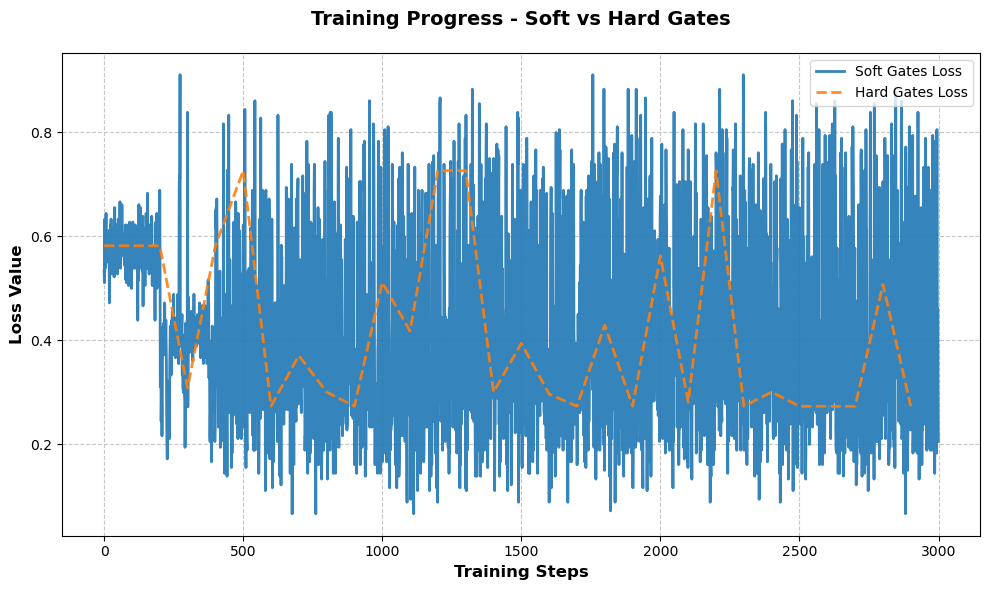

In [ ]:
# Game of life
jax.clear_caches()
N = 128

hyperparams_life = {'perceive': {}, 'update': {}}
hyperparams_life['seed'] = 23
hyperparams_life['lr'] = 0.05
hyperparams_life['batch_size'] = 20
hyperparams_life['num_epochs'] = 3000
hyperparams_life['num_steps'] = 1
hyperparams_life['channels'] = 1
hyperparams_life['perceive']['n_kernels'] = 16
hyperparams_life['perceive']['layers'] = [9, 8, 4, 2, 1]
hyperparams_life['perceive']['connections'] = [
    'first_kernel', 'unique', 'unique', 'unique',]
init_life = (hyperparams_life['perceive']['n_kernels'] * hyperparams_life['channels']
             * hyperparams_life['perceive']['layers'][-1] + hyperparams_life['channels'])
hyperparams_life['update']['layers'] = (
    [init_life] + [128] * 16 + [128, 64, 32, 16, 8, 4, 2, hyperparams_life['channels']])
hyperparams_life['update']['connections'] = [
    'unique'] * len(hyperparams_life['update']['layers'])
hyperparams_life['async_training'] = False
hyperparams_life['training'] = False
hyperparams_life['periodic'] = True


hyperparams_life.update({
    # 'dataset': 'cifar-10-3-thresholds',
    'seed': 0,
    # 'channels': 8,
    # 'batch_size': 128,
    # 'valid_set_size': 0.1,
    # 'num_workers': 0,
    # 'num_steps': 1200,
    # 'eval_every': 100,
    'learning_rate': 0.03,
    'weight_decay': 1e-4,
    'clip_value': 100.0,
    # 'connections': 'random',
    'logic_family': 'light',  # 'full' or 'light'
    # full: plain softmax / gumbel ST / dirichlet(softplus(logits)); light: 'light_st' (recommended) or 'light_sigmoid'
    'architecture': 'light_st',
    'gumb_tau': 1.0,
    'dirichlet_concentration': 12.0,
    'sum_tau': 10.0,
    # 'num_neurons': 8,
    # 'num_layers': 3,
    # 'toy_num_bits': 6,
    # 'data_roots': {
    #     'block': './blocks_dataset',
    #     'uci': './data-uci',
    #     'mnist': './data-mnist',
    #     'cifar': './data-cifar',
    # },
})

train_state, wires, apply_fn, optimizer = dlca_init_state(hyperparams_life)
train_step = make_dlca_train_step(apply_fn, optimizer, loss_fn=dlca_loss_f)


@partial(jax.jit, static_argnums=(1,))
def simulate_batch(boards, steps):
    def simulate_one(board):
        states = [board]
        for _ in range(steps):
            board = step(board)
            states.append(board)
        return jnp.stack(states)

    return jax.vmap(simulate_one)(boards)


def generate_binary_tensor():
    # Generate all possible combinations of 0s and 1s for 9 positions
    binary_numbers = jnp.arange(512)
    # Convert to binary and pad to 9 bits
    binary_array = (
        (binary_numbers[:, None] & (1 << jnp.arange(8, -1, -1))) > 0
    ).astype(jnp.float32)
    # Reshape to (512, 9, 1)
    tensor = binary_array.reshape(512, 9, 1)
    return tensor


initial_boards = generate_binary_tensor().reshape(-1, 3, 3).astype(jnp.uint8)


def sample_batch(key, trajectories, batch_size, state_size):
    n_samples = trajectories.shape[0]
    sample_idx = jax.random.randint(
        key, minval=0, maxval=n_samples, shape=(batch_size,)
    )
    init = jnp.zeros(
        (*trajectories[sample_idx, 0].shape, state_size), dtype=jnp.float32
    )
    init = init.at[..., 0].set(trajectories[sample_idx, 0])
    return init, trajectories[sample_idx, 1:, ..., None].astype(jnp.float32)


data_key = random.PRNGKey(hyperparams_life['seed'])
data_key, subkey = random.split(data_key, 2)

trajectories = simulate_batch(initial_boards, hyperparams_life['num_steps'])
full_train_x = jnp.zeros(
    (*trajectories[:, 0].shape, hyperparams_life['channels']), dtype=jnp.float32)
full_train_x = full_train_x.at[..., 0].set(trajectories[:, 0])
full_train_y = trajectories[:, 1:, ..., None].astype(jnp.float32)[:, 0, :, :]

batch_input = full_train_x
batch_output = trajectories[:, 1:, ..., None].astype(jnp.float32)

print(batch_input[8].reshape(3, 3))
print(batch_output[8, 0, :, :].reshape(3, 3))

ii = get_grid_patches(batch_input[8], 3, 1, 1)
print(ii[0].reshape(3, 3))

batch_soft_loss = []
batch_hard_loss = []
eval_soft_loss = []
eval_hard_loss = []
eval_steps = []
first_diag = None
eval_every = 100

for i in range(hyperparams_life['num_epochs']):
    data_key, sample_key = random.split(data_key, 2)
    train_x, train_y = sample_batch(
        sample_key,
        trajectories,
        hyperparams_life['batch_size'],
        hyperparams_life['channels'],
    )
    target_y = train_y[:, 0, :, :]
    train_state, soft_loss, aux = train_step(
        train_state,
        train_x,
        target_y,
        wires,
        hyperparams_life['periodic'],
        hyperparams_life['num_steps'],
        hyperparams_life['async_training'],
    )

    batch_soft = float(soft_loss)
    batch_hard = float(aux['hard'])
    batch_soft_loss.append(batch_soft)
    batch_hard_loss.append(batch_hard)

    if i == 0 or i % eval_every == 0:
        eval_diag = inspect_dlca_training_batch(
            train_state,
            full_train_x,
            full_train_y,
            wires,
            apply_fn,
            hyperparams_life['periodic'],
            hyperparams_life['num_steps'],
            hyperparams_life['async_training'],
            optimizer=optimizer,
            loss_fn=dlca_loss_f,
        )
        eval_soft_loss.append(eval_diag['soft_loss_mean'])
        eval_hard_loss.append(eval_diag['hard_loss_mean'])
        eval_steps.append(i)
        if i == 0:
            first_diag = eval_diag

    if i % eval_every == 0:
        clear_output(wait=True)
        plot_training_progress(batch_soft_loss, eval_hard_loss, eval_every)
        print(
            f"step={i} "
            f"batch_soft_mean={batch_soft:.6f} batch_hard_mean={batch_hard:.6f} "
            f"full_soft_mean={eval_soft_loss[-1]:.6f} full_hard_mean={eval_hard_loss[-1]:.6f} "
            f"grads_finite={bool(jax.device_get(aux['grads_finite']))} "
            f"updates_finite={bool(jax.device_get(aux['updates_finite']))}"
        )
        if first_diag is not None:
            print(first_diag)
            first_diag = None

clear_output(wait=True)
plot_training_progress(batch_soft_loss, eval_hard_loss,
                       eval_every, 'gof_loss.svg')

gof_loss_summary = {
    'batch_soft_last': None if not batch_soft_loss else batch_soft_loss[-1],
    'batch_hard_last': None if not batch_hard_loss else batch_hard_loss[-1],
    'full_soft_first': None if not eval_soft_loss else eval_soft_loss[0],
    'full_soft_last': None if not eval_soft_loss else eval_soft_loss[-1],
    'full_soft_best': None if not eval_soft_loss else min(eval_soft_loss),
    'full_hard_first': None if not eval_hard_loss else eval_hard_loss[0],
    'full_hard_last': None if not eval_hard_loss else eval_hard_loss[-1],
    'full_hard_best': None if not eval_hard_loss else min(eval_hard_loss),
    'eval_steps': eval_steps,
}
# train_state, wires, apply_fn, optimizer

In [ ]:
print(gof_loss_summary)
if eval_hard_loss:
    print('full_hard_eval_tail', eval_hard_loss[-10:])
if eval_soft_loss:
    print('full_soft_eval_tail', eval_soft_loss[-10:])

{'batch_soft_last': 0.20555555820465088, 'batch_hard_last': 0.20555555820465088, 'full_soft_first': 0.58203125, 'full_soft_last': 0.2734375, 'full_soft_best': 0.2734375, 'full_hard_first': 0.58203125, 'full_hard_last': 0.2734375, 'full_hard_best': 0.2734375, 'eval_steps': [0, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300, 2400, 2500, 2600, 2700, 2800, 2900]}
full_hard_eval_tail [0.5625, 0.28125, 0.7265625, 0.2734375, 0.30078125, 0.2734375, 0.2734375, 0.2734375, 0.5078125, 0.2734375]
full_soft_eval_tail [0.5625, 0.28125, 0.7265625, 0.2734375, 0.30078125, 0.2734375, 0.2734375, 0.2734375, 0.5078125, 0.2734375]


In [ ]:
# step=0 batch_soft_mean=0.533333 batch_hard_mean=0.533333 full_soft_mean=0.582031 full_hard_mean=0.582031 grads_finite=True updates_finite=True
# {'active_path': 'dlca_cell9_make_train_step', 'loss_reduction': 'mean', 'train_x_shape': (512, 3, 3, 1), 'train_y_shape': (512, 3, 3, 1), 'y_soft_shape': (512, 3, 3, 1), 'y_hard_shape': (512, 3, 3, 1), 'train_x_dtype': 'float32', 'train_y_dtype': 'float32', 'y_soft_dtype': 'float32', 'y_hard_dtype': 'float32', 'loss_shape': (), 'hard_shape': (), 'loss_scalar': True, 'hard_scalar': True, 'soft_loss_sum': 2682.0, 'hard_loss_sum': 2682.0, 'soft_loss_mean': 0.58203125, 'hard_loss_mean': 0.58203125, 'element_count': 4608, 'grads_finite': True, 'params_finite': True, 'grad_l2': 0.00020035082707181573, 'same_rng_root_for_soft_and_hard': True, 'updates_finite': True, 'update_l2': 0.25672537088394165}